In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset de residuos plásticos por ciudad en Colombia
# Fuentes: DANE, IDEAM, Ministerio de Ambiente 2023
datos = {
    "ciudad": [
        "Bogotá", "Medellín", "Cali", "Barranquilla", "Cartagena",
        "Bucaramanga", "Pereira", "Manizales", "Santa Marta", "Cúcuta"
    ],
    "departamento": [
        "Cundinamarca", "Antioquia", "Valle del Cauca", "Atlántico", "Bolívar",
        "Santander", "Risaralda", "Caldas", "Magdalena", "Norte de Santander"
    ],
    "poblacion_miles": [
        8034, 2572, 2228, 1274, 1001,
        605, 484, 434, 523, 750
    ],
    "residuos_plastico_ton_dia": [
        850, 245, 198, 145, 98,
        67, 52, 44, 48, 78
    ],
    "pct_reciclado": [
        17, 23, 15, 12, 10,
        19, 21, 25, 8, 11
    ],
    "pct_relleno_sanitario": [
        68, 62, 72, 75, 78,
        65, 63, 58, 80, 76
    ],
    "pct_disposicion_inadecuada": [
        15, 15, 13, 13, 12,
        16, 16, 17, 12, 13
    ],
    "empresas_recicladoras": [
        145, 89, 62, 38, 22,
        31, 28, 24, 12, 18
    ],
    "meta_reciclaje_2030_pct": [
        30, 35, 28, 25, 22,
        30, 32, 35, 20, 25
    ],
    "region": [
        "Centro", "Andina", "Pacífica", "Caribe", "Caribe",
        "Andina", "Andina", "Andina", "Caribe", "Andina"
    ]
}

df = pd.DataFrame(datos)
print("✅ Dataset cargado")
print(f"Ciudades: {df.shape[0]} | Variables: {df.shape[1]}")
print("\nPrimeras filas:")
print(df[["ciudad", "residuos_plastico_ton_dia", "pct_reciclado", "region"]].head(5))

✅ Dataset cargado
Ciudades: 10 | Variables: 10

Primeras filas:
         ciudad  residuos_plastico_ton_dia  pct_reciclado    region
0        Bogotá                        850             17    Centro
1      Medellín                        245             23    Andina
2          Cali                        198             15  Pacífica
3  Barranquilla                        145             12    Caribe
4     Cartagena                         98             10    Caribe


In [2]:
# EXPLORACIÓN Y LIMPIEZA
print("=== Tipos de datos ===")
print(df.dtypes)

print("\n=== Valores vacíos ===")
print(df.isnull().sum())

print("\n=== Estadísticas generales ===")
print(df[["residuos_plastico_ton_dia", "pct_reciclado",
          "pct_relleno_sanitario", "pct_disposicion_inadecuada"]].describe().round(1))

print("\n=== Verificación de coherencia ===")
df["suma_pct"] = df["pct_reciclado"] + df["pct_relleno_sanitario"] + df["pct_disposicion_inadecuada"]
print("Suma de porcentajes por ciudad (debe ser 100%):")
print(df[["ciudad", "suma_pct"]].to_string(index=False))

print("\n=== Residuos por región ===")
print(df.groupby("region")["residuos_plastico_ton_dia"].sum().sort_values(ascending=False))

=== Tipos de datos ===
ciudad                        object
departamento                  object
poblacion_miles                int64
residuos_plastico_ton_dia      int64
pct_reciclado                  int64
pct_relleno_sanitario          int64
pct_disposicion_inadecuada     int64
empresas_recicladoras          int64
meta_reciclaje_2030_pct        int64
region                        object
dtype: object

=== Valores vacíos ===
ciudad                        0
departamento                  0
poblacion_miles               0
residuos_plastico_ton_dia     0
pct_reciclado                 0
pct_relleno_sanitario         0
pct_disposicion_inadecuada    0
empresas_recicladoras         0
meta_reciclaje_2030_pct       0
region                        0
dtype: int64

=== Estadísticas generales ===
       residuos_plastico_ton_dia  pct_reciclado  pct_relleno_sanitario  \
count                       10.0           10.0                   10.0   
mean                       182.5           16.1         

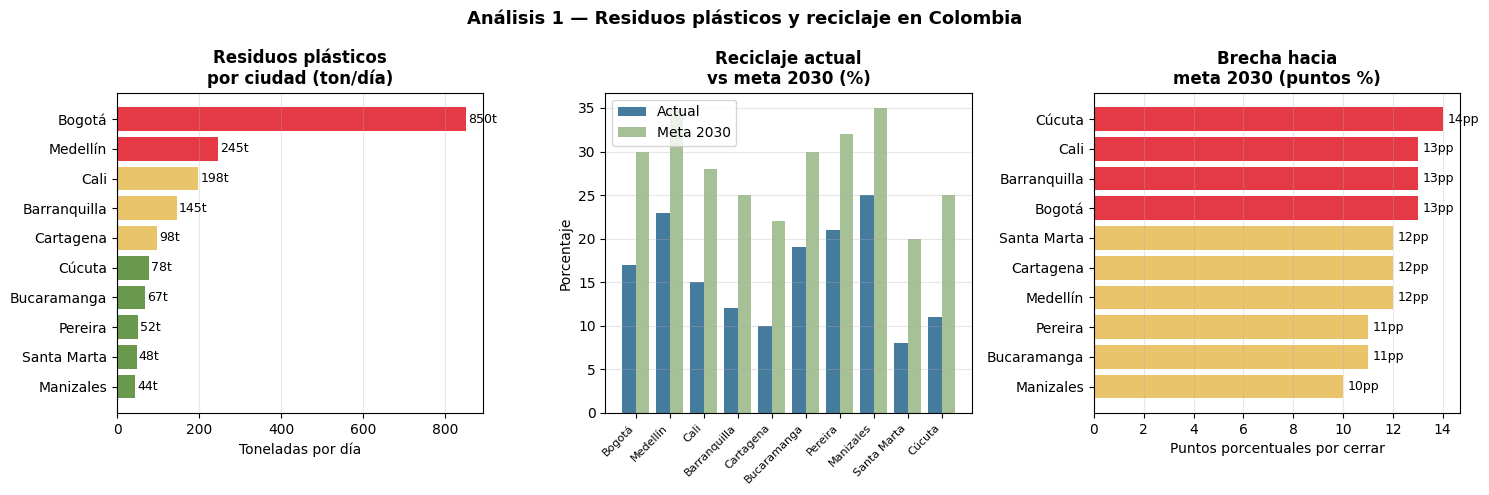


Hallazgos:
  Mejor reciclaje    : Manizales (25%)
  Peor reciclaje     : Santa Marta (8%)
  Mayor brecha 2030  : Cúcuta (14 puntos %)
  Promedio reciclaje : 16.1%


In [3]:
# Eliminamos columna auxiliar
df = df.drop(columns=["suma_pct"])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfica 1 — Residuos por ciudad
df_sorted = df.sort_values("residuos_plastico_ton_dia", ascending=True)
colores = ["#E63946" if v > 200 else "#E9C46A" if v > 80 else "#6A994E"
           for v in df_sorted["residuos_plastico_ton_dia"]]
axes[0].barh(df_sorted["ciudad"], df_sorted["residuos_plastico_ton_dia"], color=colores)
for i, val in enumerate(df_sorted["residuos_plastico_ton_dia"]):
    axes[0].text(val + 5, i, f"{val}t", va="center", fontsize=9)
axes[0].set_title("Residuos plásticos\npor ciudad (ton/día)", fontweight="bold")
axes[0].set_xlabel("Toneladas por día")
axes[0].grid(axis="x", alpha=0.3)

# Gráfica 2 — % Reciclado vs meta 2030
x = range(len(df))
axes[1].bar([i - 0.2 for i in x], df["pct_reciclado"],
            width=0.4, color="#457B9D", label="Actual")
axes[1].bar([i + 0.2 for i in x], df["meta_reciclaje_2030_pct"],
            width=0.4, color="#6A994E", alpha=0.6, label="Meta 2030")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(df["ciudad"], rotation=45, ha="right", fontsize=8)
axes[1].set_title("Reciclaje actual\nvs meta 2030 (%)", fontweight="bold")
axes[1].set_ylabel("Porcentaje")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

# Gráfica 3 — Brecha hacia la meta
df["brecha_meta"] = df["meta_reciclaje_2030_pct"] - df["pct_reciclado"]
df_brecha = df.sort_values("brecha_meta", ascending=True)
colores_b = ["#E63946" if v > 12 else "#E9C46A" if v > 8 else "#6A994E"
             for v in df_brecha["brecha_meta"]]
axes[2].barh(df_brecha["ciudad"], df_brecha["brecha_meta"], color=colores_b)
for i, val in enumerate(df_brecha["brecha_meta"]):
    axes[2].text(val + 0.2, i, f"{val}pp", va="center", fontsize=9)
axes[2].set_title("Brecha hacia\nmeta 2030 (puntos %)", fontweight="bold")
axes[2].set_xlabel("Puntos porcentuales por cerrar")
axes[2].grid(axis="x", alpha=0.3)

plt.suptitle("Análisis 1 — Residuos plásticos y reciclaje en Colombia",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nHallazgos:")
mejor_reciclaje = df.loc[df["pct_reciclado"].idxmax(), "ciudad"]
peor_reciclaje = df.loc[df["pct_reciclado"].idxmin(), "ciudad"]
mayor_brecha = df.loc[df["brecha_meta"].idxmax(), "ciudad"]
print(f"  Mejor reciclaje    : {mejor_reciclaje} ({df['pct_reciclado'].max()}%)")
print(f"  Peor reciclaje     : {peor_reciclaje} ({df['pct_reciclado'].min()}%)")
print(f"  Mayor brecha 2030  : {mayor_brecha} ({df['brecha_meta'].max()} puntos %)")
print(f"  Promedio reciclaje : {df['pct_reciclado'].mean():.1f}%")

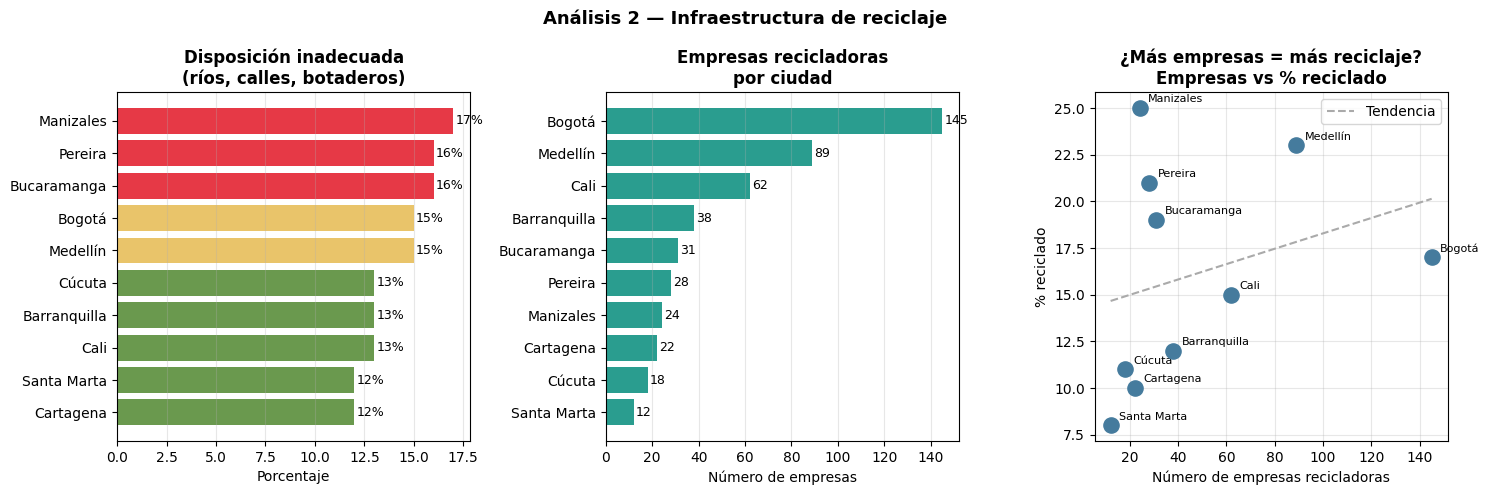


Hallazgos:
  Ciudad con más empresas recicladoras  : Bogotá (145)
  Ciudad con menos empresas recicladoras: Santa Marta (12)
  Total toneladas disposición inadecuada: 263.0 ton/día


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfica 1 — Disposición inadecuada
df_sorted2 = df.sort_values("pct_disposicion_inadecuada", ascending=True)
colores_d = ["#E63946" if v > 15 else "#E9C46A" if v > 13 else "#6A994E"
             for v in df_sorted2["pct_disposicion_inadecuada"]]
axes[0].barh(df_sorted2["ciudad"], df_sorted2["pct_disposicion_inadecuada"], color=colores_d)
for i, val in enumerate(df_sorted2["pct_disposicion_inadecuada"]):
    axes[0].text(val + 0.1, i, f"{val}%", va="center", fontsize=9)
axes[0].set_title("Disposición inadecuada\n(ríos, calles, botaderos)", fontweight="bold")
axes[0].set_xlabel("Porcentaje")
axes[0].grid(axis="x", alpha=0.3)

# Gráfica 2 — Empresas recicladoras
df_sorted3 = df.sort_values("empresas_recicladoras", ascending=True)
axes[1].barh(df_sorted3["ciudad"], df_sorted3["empresas_recicladoras"], color="#2A9D8F")
for i, val in enumerate(df_sorted3["empresas_recicladoras"]):
    axes[1].text(val + 1, i, str(val), va="center", fontsize=9)
axes[1].set_title("Empresas recicladoras\npor ciudad", fontweight="bold")
axes[1].set_xlabel("Número de empresas")
axes[1].grid(axis="x", alpha=0.3)

# Gráfica 3 — Relación empresas vs reciclaje
axes[2].scatter(df["empresas_recicladoras"], df["pct_reciclado"],
               color="#457B9D", s=120, zorder=5)
for _, row in df.iterrows():
    axes[2].annotate(row["ciudad"],
                    (row["empresas_recicladoras"], row["pct_reciclado"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)
import numpy as np
z = np.polyfit(df["empresas_recicladoras"], df["pct_reciclado"], 1)
p = np.poly1d(z)
x_line = sorted(df["empresas_recicladoras"])
axes[2].plot(x_line, p(x_line), "--", color="#aaaaaa", linewidth=1.5, label="Tendencia")
axes[2].set_title("¿Más empresas = más reciclaje?\nEmpresas vs % reciclado", fontweight="bold")
axes[2].set_xlabel("Número de empresas recicladoras")
axes[2].set_ylabel("% reciclado")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("Análisis 2 — Infraestructura de reciclaje",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nHallazgos:")
print(f"  Ciudad con más empresas recicladoras  : {df.loc[df['empresas_recicladoras'].idxmax(), 'ciudad']} ({df['empresas_recicladoras'].max()})")
print(f"  Ciudad con menos empresas recicladoras: {df.loc[df['empresas_recicladoras'].idxmin(), 'ciudad']} ({df['empresas_recicladoras'].min()})")
print(f"  Total toneladas disposición inadecuada: {(df['residuos_plastico_ton_dia'] * df['pct_disposicion_inadecuada'] / 100).sum():.1f} ton/día")

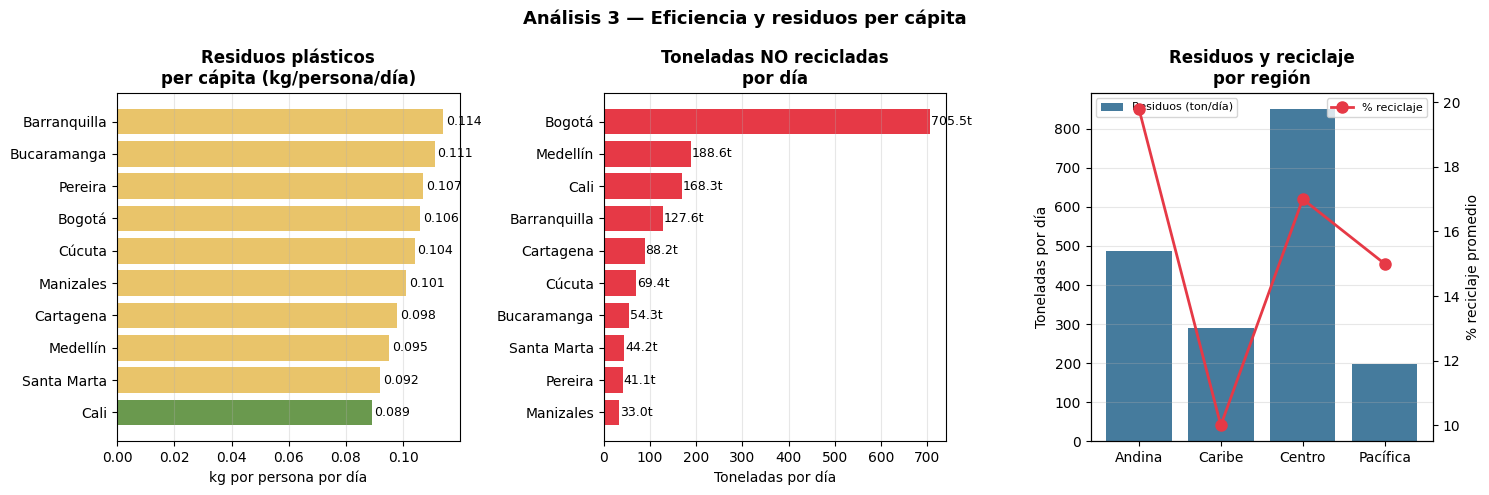


Hallazgos per cápita:
  Mayor consumo per cápita : Barranquilla (0.114 kg/persona/día)
  Menor consumo per cápita : Cali (0.089 kg/persona/día)
  Total no reciclado/día   : 1520 toneladas

Por región:
          residuos_total  reciclaje_promedio
region                                      
Andina               486                19.8
Caribe               291                10.0
Centro               850                17.0
Pacífica             198                15.0


In [6]:
# Calcular indicadores per cápita
df["residuos_kg_persona_dia"] = (df["residuos_plastico_ton_dia"] * 1000 /
                                  (df["poblacion_miles"] * 1000)).round(3)
df["ton_no_recicladas_dia"] = (df["residuos_plastico_ton_dia"] *
                                (100 - df["pct_reciclado"]) / 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfica 1 — Residuos per cápita
df_pc = df.sort_values("residuos_kg_persona_dia", ascending=True)
colores_pc = ["#E63946" if v > 0.12 else "#E9C46A" if v > 0.09 else "#6A994E"
              for v in df_pc["residuos_kg_persona_dia"]]
axes[0].barh(df_pc["ciudad"], df_pc["residuos_kg_persona_dia"], color=colores_pc)
for i, val in enumerate(df_pc["residuos_kg_persona_dia"]):
    axes[0].text(val + 0.001, i, f"{val:.3f}", va="center", fontsize=9)
axes[0].set_title("Residuos plásticos\nper cápita (kg/persona/día)", fontweight="bold")
axes[0].set_xlabel("kg por persona por día")
axes[0].grid(axis="x", alpha=0.3)

# Gráfica 2 — Toneladas no recicladas por día
df_nr = df.sort_values("ton_no_recicladas_dia", ascending=True)
axes[1].barh(df_nr["ciudad"], df_nr["ton_no_recicladas_dia"], color="#E63946")
for i, val in enumerate(df_nr["ton_no_recicladas_dia"]):
    axes[1].text(val + 2, i, f"{val}t", va="center", fontsize=9)
axes[1].set_title("Toneladas NO recicladas\npor día", fontweight="bold")
axes[1].set_xlabel("Toneladas por día")
axes[1].grid(axis="x", alpha=0.3)

# Gráfica 3 — Comparación por región
region_data = df.groupby("region").agg(
    residuos_total=("residuos_plastico_ton_dia", "sum"),
    reciclaje_promedio=("pct_reciclado", "mean")
).round(1)
x_reg = range(len(region_data))
axes[2].bar(region_data.index, region_data["residuos_total"], color="#457B9D", label="Residuos (ton/día)")
ax2 = axes[2].twinx()
ax2.plot(region_data.index, region_data["reciclaje_promedio"],
         "o-", color="#E63946", linewidth=2, markersize=8, label="% reciclaje")
axes[2].set_title("Residuos y reciclaje\npor región", fontweight="bold")
axes[2].set_ylabel("Toneladas por día")
ax2.set_ylabel("% reciclaje promedio")
axes[2].legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Análisis 3 — Eficiencia y residuos per cápita",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nHallazgos per cápita:")
mayor_pc = df.loc[df["residuos_kg_persona_dia"].idxmax()]
menor_pc = df.loc[df["residuos_kg_persona_dia"].idxmin()]
print(f"  Mayor consumo per cápita : {mayor_pc['ciudad']} ({mayor_pc['residuos_kg_persona_dia']:.3f} kg/persona/día)")
print(f"  Menor consumo per cápita : {menor_pc['ciudad']} ({menor_pc['residuos_kg_persona_dia']:.3f} kg/persona/día)")
print(f"  Total no reciclado/día   : {df['ton_no_recicladas_dia'].sum():.0f} toneladas")
print(f"\nPor región:")
print(region_data.to_string())

In [7]:
# INFORME FINAL
print("=" * 58)
print("   RESIDUOS PLÁSTICOS EN COLOMBIA — 10 CIUDADES")
print("   Fuentes: DANE, IDEAM, Ministerio de Ambiente 2023")
print("=" * 58)

total_residuos = df["residuos_plastico_ton_dia"].sum()
total_reciclado = (df["residuos_plastico_ton_dia"] * df["pct_reciclado"] / 100).sum()
total_inadecuado = (df["residuos_plastico_ton_dia"] * df["pct_disposicion_inadecuada"] / 100).sum()

print(f"""
HALLAZGO 1 — PANORAMA GENERAL
--------------------------------
Total residuos plásticos/día  : {total_residuos:,.0f} toneladas
Total reciclado/día           : {total_reciclado:,.0f} toneladas ({total_reciclado/total_residuos*100:.1f}%)
Total NO reciclado/día        : {df['ton_no_recicladas_dia'].sum():,.0f} toneladas
Disposición inadecuada/día    : {total_inadecuado:,.0f} toneladas
Promedio reciclaje            : {df['pct_reciclado'].mean():.1f}%

HALLAZGO 2 — MEJORES Y PEORES
--------------------------------
Mejor reciclaje   : Manizales (25%) — ciudad andina mediana
Peor reciclaje    : Santa Marta (8%) — ciudad costera turística
Mayor per cápita  : Barranquilla (0.114 kg/persona/día)
Menor per cápita  : Cali (0.089 kg/persona/día)
Mayor brecha 2030 : Cúcuta (14 puntos % por cerrar)

HALLAZGO 3 — INFRAESTRUCTURA
--------------------------------
Ciudad más empresas recicladoras : Bogotá (145)
Ciudad menos empresas            : Santa Marta (12)
Región más crítica               : Caribe (10% reciclaje promedio)
Región más avanzada              : Andina (19.8% reciclaje promedio)

HALLAZGO 4 — PROYECCIÓN ANUAL
--------------------------------
Plástico no reciclado/año : {df['ton_no_recicladas_dia'].sum()*365:,.0f} toneladas
Disposición inadecuada/año: {total_inadecuado*365:,.0f} toneladas
Equivale a llenar         : {int(total_inadecuado*365/500):,} piscinas olímpicas

RECOMENDACIONES
-----------------
1. Priorizar inversión en reciclaje en región Caribe
2. Replicar modelo de Manizales en ciudades rezagadas
3. Aumentar empresas recicladoras en Santa Marta y Cartagena
4. Educación ambiental para reducir consumo per cápita
5. Meta nacional mínima de 25% reciclaje para 2030
""")
print("=" * 58)

   RESIDUOS PLÁSTICOS EN COLOMBIA — 10 CIUDADES
   Fuentes: DANE, IDEAM, Ministerio de Ambiente 2023

HALLAZGO 1 — PANORAMA GENERAL
--------------------------------
Total residuos plásticos/día  : 1,825 toneladas
Total reciclado/día           : 305 toneladas (16.7%)
Total NO reciclado/día        : 1,520 toneladas
Disposición inadecuada/día    : 263 toneladas
Promedio reciclaje            : 16.1%

HALLAZGO 2 — MEJORES Y PEORES
--------------------------------
Mejor reciclaje   : Manizales (25%) — ciudad andina mediana
Peor reciclaje    : Santa Marta (8%) — ciudad costera turística
Mayor per cápita  : Barranquilla (0.114 kg/persona/día)
Menor per cápita  : Cali (0.089 kg/persona/día)
Mayor brecha 2030 : Cúcuta (14 puntos % por cerrar)

HALLAZGO 3 — INFRAESTRUCTURA
--------------------------------
Ciudad más empresas recicladoras : Bogotá (145)
Ciudad menos empresas            : Santa Marta (12)
Región más crítica               : Caribe (10% reciclaje promedio)
Región más avanzada        

In [9]:
# Exportar para SQL
df.to_csv("plastico_colombia.csv", index=False)
print("✅ Archivo exportado")

✅ Archivo exportado
